# TLC e Lei dos Grandes Números

**Tema:** Estatística › Distribuições de Probabilidade

Estes são os dois teoremas que fazem a estatística inteira funcionar. Sem eles,
não haveria intervalo de confiança, teste A/B, nem barra de erro em gráfico
nenhum.

Mas eles têm **condições**, e essas condições falham em dados reais com mais
frequência do que os cursos admitem. O objetivo aqui é: entender os teoremas
*e* saber reconhecer quando não confiar neles.

> **Analogia:** a Lei dos Grandes Números diz que a média amostral *chega* no
> lugar certo. O Teorema Central do Limite diz *com que precisão* ela chega, a
> cada tamanho de amostra. Um garante o destino; o outro entrega o GPS.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(314)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86"
print("pronto")

pronto


## 1. Lei dos Grandes Números: a média chega lá

$$\bar{X}_n \longrightarrow \mu \qquad \text{quando } n \to \infty$$

Vamos ver a convergência acontecer em quatro distribuições muito diferentes.

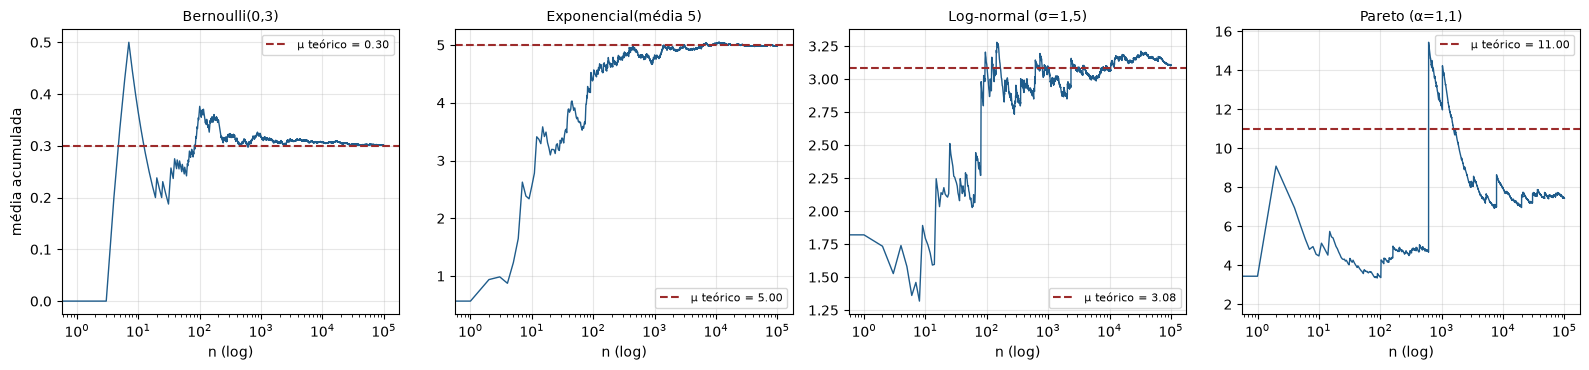

processo                   μ teórico   média com n=100k  erro relativo
------------------------------------------------------------------------
Bernoulli(0,3)                 0.300              0.301          0.2%
Exponencial(média 5)           5.000              4.987          0.3%
Log-normal (σ=1,5)             3.080              3.107          0.9%
Pareto (α=1,1)                11.000              7.438         32.4%


In [2]:
N_MAX = 100_000
processos = {
    "Bernoulli(0,3)": (rng.random(N_MAX) < 0.3).astype(float),
    "Exponencial(média 5)": rng.exponential(5, N_MAX),
    "Log-normal (σ=1,5)": rng.lognormal(0, 1.5, N_MAX),
    "Pareto (α=1,1)": (rng.pareto(1.1, N_MAX) + 1),
}
medias_teoricas = {
    "Bernoulli(0,3)": 0.3,
    "Exponencial(média 5)": 5.0,
    "Log-normal (σ=1,5)": np.exp(0 + 1.5**2 / 2),
    "Pareto (α=1,1)": 1.1 / (1.1 - 1),          # α/(α-1), quase 11 mas instável
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, (nome, v) in zip(axes, processos.items()):
    acumulada = np.cumsum(v) / np.arange(1, N_MAX + 1)
    ax.plot(acumulada, lw=1, color=AZUL)
    ax.axhline(medias_teoricas[nome], ls="--", color=VERMELHO, lw=1.5,
               label=f"μ teórico = {medias_teoricas[nome]:.2f}")
    ax.set_xscale("log")
    ax.set_title(nome, fontsize=10)
    ax.set_xlabel("n (log)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("média acumulada")
plt.tight_layout()
plt.show()

print(f"{'processo':24s} {'μ teórico':>11s} {'média com n=100k':>18s} {'erro relativo':>14s}")
print("-" * 72)
for nome, v in processos.items():
    obs = v.mean()
    teo = medias_teoricas[nome]
    print(f"{nome:24s} {teo:>11.3f} {obs:>18.3f} {abs(obs-teo)/teo:>13.1%}")

Os três primeiros convergem. O quarto — **Pareto com $\alpha = 1{,}1$** — não.
Com 100 mil observações o erro ainda é enorme, e a curva dá saltos permanentes.

A razão é matemática e não tem conserto por força bruta: para
$\alpha \leq 2$ a **variância é infinita**, e para $\alpha \leq 1$ a própria
**média** é infinita. A LGN exige uma média finita para existir um destino.

> **No mercado:** danos de catástrofe, valor de contratos enterprise, tamanho
> de arquivos, tráfego por post viral. Nesses domínios, "aumentar a amostra"
> **não** estabiliza a média. A resposta correta é modelar a cauda
> explicitamente (teoria de valores extremos) ou usar estatísticas robustas.

## 2. Teorema Central do Limite: a forma da incerteza

$$\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \longrightarrow \mathcal{N}(0,1)$$

O ponto extraordinário: **quase não importa de onde os dados vêm**. A média de
amostras de qualquer distribuição de variância finita vira normal.

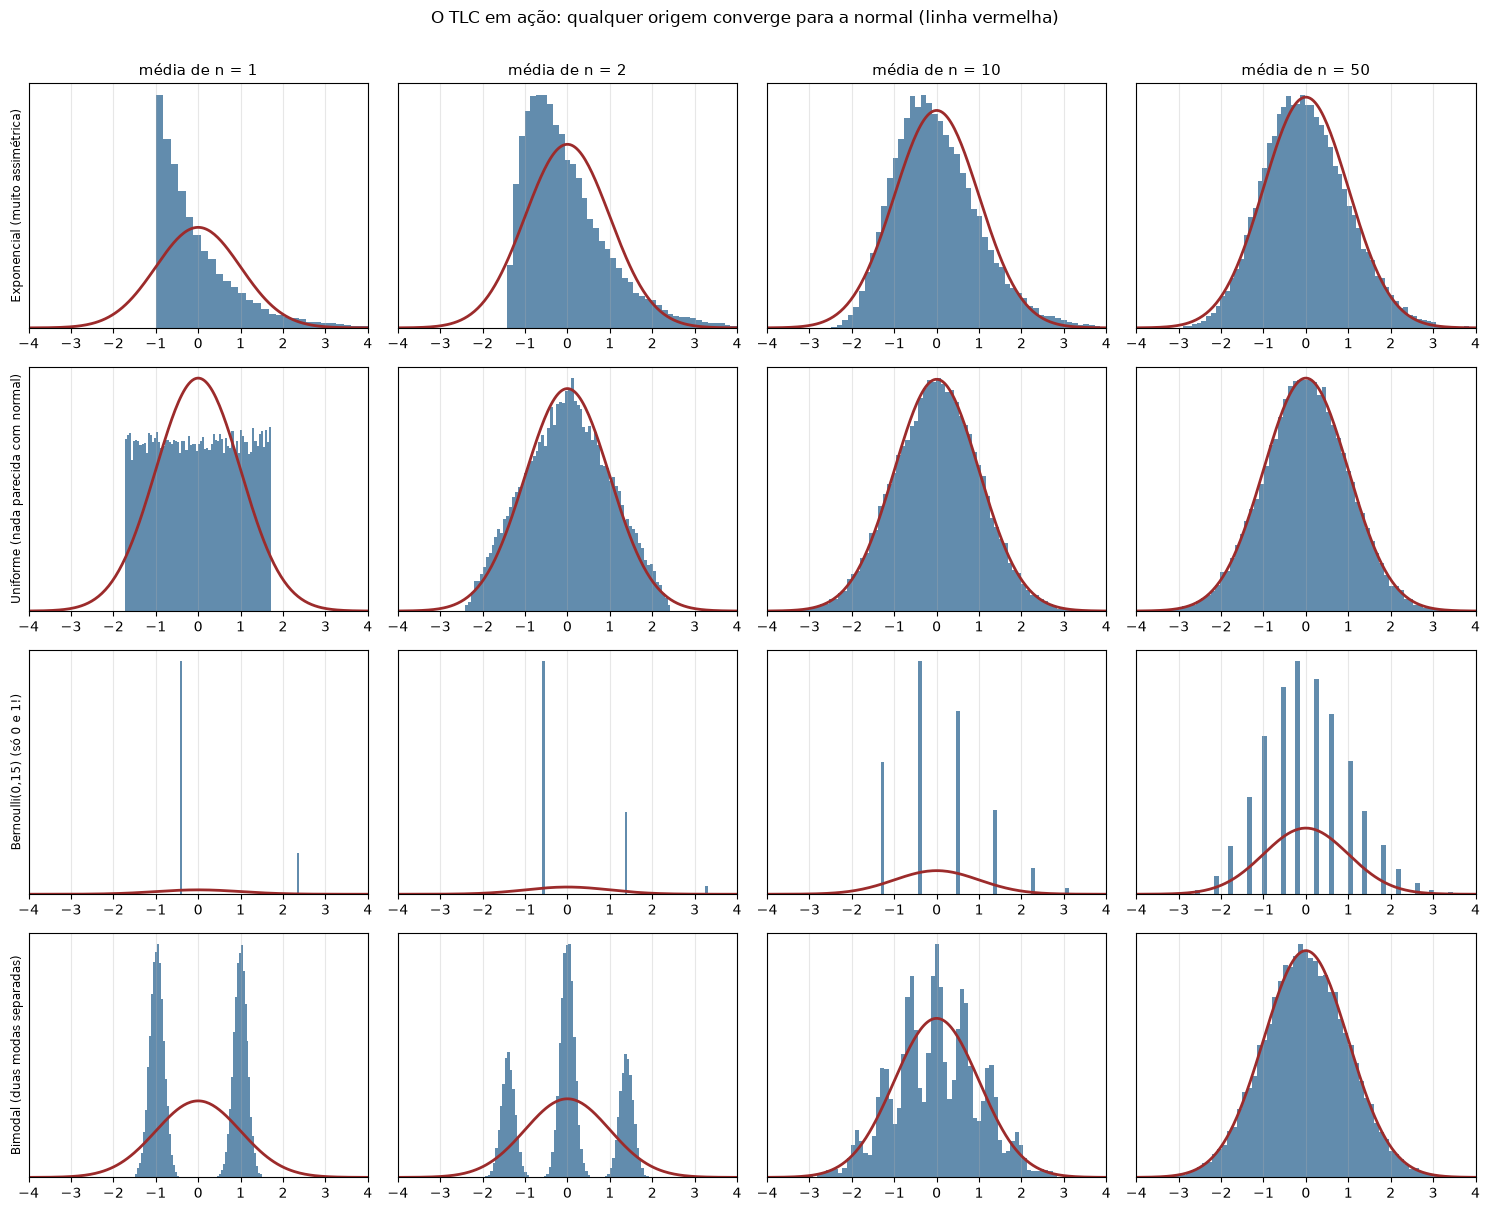

In [3]:
N_EXPERIMENTOS = 30_000
fontes = {
    "Exponencial (muito assimétrica)": lambda k: rng.exponential(1.0, k),
    "Uniforme (nada parecida com normal)": lambda k: rng.uniform(0, 1, k),
    "Bernoulli(0,15) (só 0 e 1!)": lambda k: (rng.random(k) < 0.15).astype(float),
    "Bimodal (duas modas separadas)": lambda k: np.where(
        rng.random(k) < 0.5, rng.normal(-3, 0.5, k), rng.normal(3, 0.5, k)),
}

fig, axes = plt.subplots(len(fontes), 4, figsize=(15, 12))
for linha, (nome, gerador) in enumerate(fontes.items()):
    for coluna, n in enumerate([1, 2, 10, 50]):
        # n=1 mostra a distribuição ORIGINAL; os demais, a média de n observações
        medias = gerador(N_EXPERIMENTOS * n).reshape(N_EXPERIMENTOS, n).mean(axis=1)
        z = (medias - medias.mean()) / medias.std(ddof=1)
        ax = axes[linha, coluna]
        ax.hist(z, bins=70, density=True, color=AZUL, alpha=0.7, edgecolor="none")
        grade = np.linspace(-4, 4, 200)
        ax.plot(grade, stats.norm.pdf(grade), lw=2, color=VERMELHO)
        ax.set_xlim(-4, 4)
        ax.set_yticks([])
        if linha == 0:
            ax.set_title(f"média de n = {n}", fontsize=11)
        if coluna == 0:
            ax.set_ylabel(nome, fontsize=8.5)
plt.suptitle("O TLC em ação: qualquer origem converge para a normal (linha vermelha)",
             y=1.005, fontsize=12)
plt.tight_layout()
plt.show()

A linha da **Bernoulli** é a mais impressionante: a distribuição original só
tem dois valores possíveis (0 e 1), nada poderia ser menos normal. Com $n=50$ a
média já é bem aproximada por uma normal.

## 3. "n ≥ 30" é uma regra de bolso, não um teorema

A velocidade de convergência depende da **assimetria** da origem. Vamos medir.

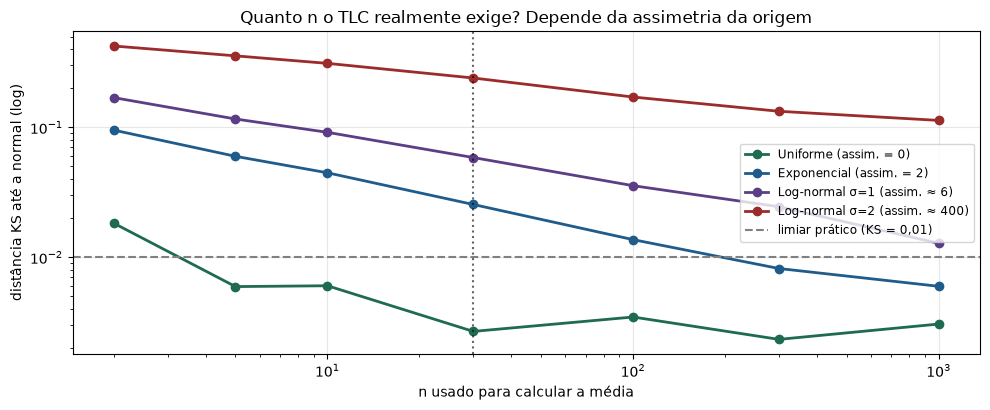

,Uniforme (assim. = 0),Exponencial (assim. = 2),Log-normal σ=1 (assim. ≈ 6),Log-normal σ=2 (assim. ≈ 400)
n,,,,
2,0.0183,0.0952,0.1695,0.4234
5,0.0059,0.0599,0.1160,0.3555
10,0.0060,0.0447,0.0916,0.3112
30,0.0027,0.0255,0.0586,0.2400
100,0.0035,0.0137,0.0356,0.1713
300,0.0023,0.0082,0.0245,0.1330
1000,0.0031,0.0060,0.0128,0.1131


In [4]:
def erro_de_normalidade(gerador, n, n_exp=40_000):
    """Distância de Kolmogorov-Smirnov entre a média padronizada e a N(0,1).

    Quanto menor, mais 'já convergiu'. É uma medida direta de quão errado
    estaria um intervalo de confiança construído com a aproximação normal.
    """
    medias = gerador(n_exp * n).reshape(n_exp, n).mean(axis=1)
    z = (medias - medias.mean()) / medias.std(ddof=1)
    return stats.kstest(z, "norm").statistic

geradores = {
    "Uniforme (assim. = 0)": lambda k: rng.uniform(0, 1, k),
    "Exponencial (assim. = 2)": lambda k: rng.exponential(1, k),
    "Log-normal σ=1 (assim. ≈ 6)": lambda k: rng.lognormal(0, 1, k),
    "Log-normal σ=2 (assim. ≈ 400)": lambda k: rng.lognormal(0, 2, k),
}
tamanhos = [2, 5, 10, 30, 100, 300, 1000]

tabela = pd.DataFrame(
    {nome: [erro_de_normalidade(g, n) for n in tamanhos]
     for nome, g in geradores.items()},
    index=pd.Index(tamanhos, name="n"))

fig, ax = plt.subplots(figsize=(10, 4.2))
for (nome, serie), cor in zip(tabela.items(), [VERDE, AZUL, ROXO, VERMELHO]):
    ax.plot(tabela.index, serie, "o-", lw=2, label=nome, color=cor)
ax.axhline(0.01, ls="--", color="gray", label="limiar prático (KS = 0,01)")
ax.axvline(30, ls=":", color="black", alpha=0.6)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n usado para calcular a média")
ax.set_ylabel("distância KS até a normal (log)")
ax.set_title("Quanto n o TLC realmente exige? Depende da assimetria da origem")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

tabela.round(4)

A linha vertical pontilhada é o famoso "n = 30". Leia a tabela:

* **Uniforme:** já está ótimo com $n = 5$.
* **Exponencial:** aceitável em $n = 30$.
* **Log-normal $\sigma=2$:** ainda **ruim com $n = 1000$**.

> **Consequência direta:** se sua métrica é receita por usuário (log-normal com
> $\sigma$ alto), um teste t com algumas centenas de usuários por grupo pode ter
> taxa de erro tipo I bem acima dos 5% nominais. As alternativas corretas são
> **bootstrap**, **teste de permutação**, ou transformar a métrica (log,
> winsorização) — assunto dos módulos 03 e 04.

## 4. A economia do $\sqrt{n}$

O erro-padrão da média é $\sigma/\sqrt{n}$. A raiz quadrada tem uma
consequência econômica brutal.

     n erro-padrão n relativo ao 1º erro relativo ao 1º
   100     0.10000               1x              1.000x
   400     0.05000               4x              0.500x
  1600     0.02500              16x              0.250x
  6400     0.01250              64x              0.125x
 25600     0.00625             256x              0.062x
102400     0.00313           1,024x              0.031x

Para reduzir o erro pela METADE é preciso QUADRUPLICAR a amostra.
Para reduzir a UM DÉCIMO, multiplicar a amostra por CEM.


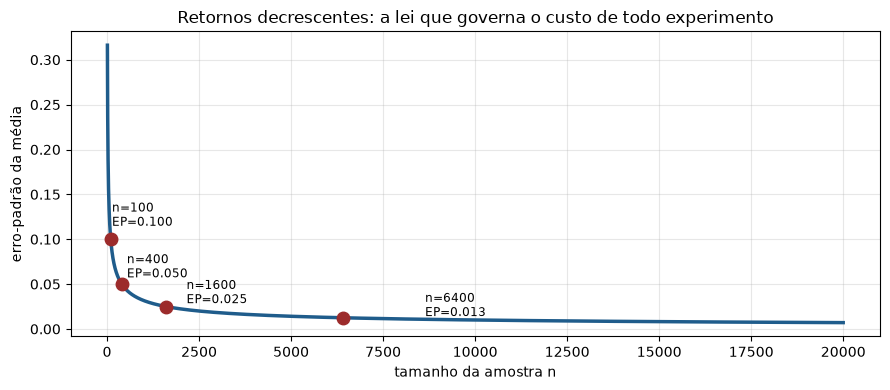

In [5]:
sigma = 1.0
ns = np.array([100, 400, 1_600, 6_400, 25_600, 102_400])
erro_padrao = sigma / np.sqrt(ns)

comparacao = pd.DataFrame({
    "n": ns,
    "erro-padrão": erro_padrao,
    "n relativo ao 1º": ns / ns[0],
    "erro relativo ao 1º": erro_padrao / erro_padrao[0],
})
print(comparacao.to_string(index=False,
      formatters={"erro-padrão": "{:.5f}".format,
                  "n relativo ao 1º": "{:,.0f}x".format,
                  "erro relativo ao 1º": "{:.3f}x".format}))

print("\nPara reduzir o erro pela METADE é preciso QUADRUPLICAR a amostra.")
print("Para reduzir a UM DÉCIMO, multiplicar a amostra por CEM.")

fig, ax = plt.subplots(figsize=(9, 4))
grade_n = np.arange(10, 20_000)
ax.plot(grade_n, sigma / np.sqrt(grade_n), lw=2.5, color=AZUL)
for marca in [100, 400, 1600, 6400]:
    ax.plot(marca, sigma / np.sqrt(marca), "o", ms=9, color=VERMELHO)
    ax.annotate(f"n={marca}\nEP={sigma/np.sqrt(marca):.3f}",
                xy=(marca, sigma/np.sqrt(marca)),
                xytext=(marca*1.35, sigma/np.sqrt(marca)*1.15), fontsize=8.5)
ax.set_xlabel("tamanho da amostra n")
ax.set_ylabel("erro-padrão da média")
ax.set_title("Retornos decrescentes: a lei que governa o custo de todo experimento")
plt.tight_layout()
plt.show()

> **No mercado:** este gráfico é a razão pela qual times de produto brigam por
> tráfego. Passar de 6 400 para 25 600 usuários num teste custa 4× mais tempo
> de exposição e só melhora a precisão em 2×. É também por isso que **reduzir a
> variância** (via CUPED, estratificação, escolha de métrica) vale muito mais
> que aumentar a amostra — e é o tema do módulo de A/B testing.

## 5. Onde o TLC quebra: variância infinita

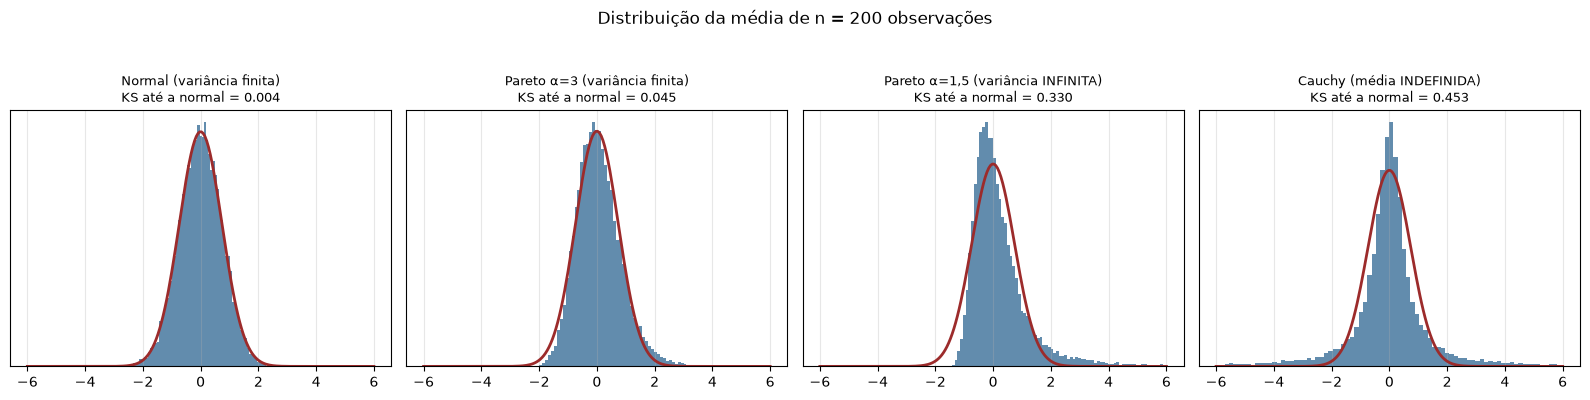

In [6]:
N_EXP, N_MED = 20_000, 200
casos = {
    "Normal (variância finita)": rng.normal(0, 1, (N_EXP, N_MED)),
    "Pareto α=3 (variância finita)": rng.pareto(3.0, (N_EXP, N_MED)) + 1,
    "Pareto α=1,5 (variância INFINITA)": rng.pareto(1.5, (N_EXP, N_MED)) + 1,
    "Cauchy (média INDEFINIDA)": rng.standard_cauchy((N_EXP, N_MED)),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, (nome, m) in zip(axes, casos.items()):
    medias = m.mean(axis=1)
    z = (medias - np.median(medias)) / stats.iqr(medias)   # escala robusta
    z = z[np.abs(z) < 6]                                   # recorta para visualizar
    ax.hist(z, bins=80, density=True, color=AZUL, alpha=0.7, edgecolor="none")
    grade = np.linspace(-6, 6, 200)
    # normal com a mesma escala robusta, para comparação visual justa
    ax.plot(grade, stats.norm.pdf(grade, 0, 1 / 1.349), lw=2, color=VERMELHO)
    ks = stats.kstest((medias - medias.mean()) / medias.std(ddof=1), "norm").statistic
    ax.set_title(f"{nome}\nKS até a normal = {ks:.3f}", fontsize=9)
    ax.set_yticks([])
plt.suptitle(f"Distribuição da média de n = {N_MED} observações", y=1.04)
plt.tight_layout()
plt.show()

Os dois primeiros painéis são normais, como o TLC promete. O terceiro é
assimétrico e com cauda. O quarto — **Cauchy** — é o caso patológico clássico:
a média de $n$ observações Cauchy tem **exatamente a mesma distribuição** de
uma única observação. Promediar não ajuda em nada.

In [7]:
uma = rng.standard_cauchy(200_000)
media_de_1000 = rng.standard_cauchy((200_000, 1000)).mean(axis=1)
print("Cauchy — comparação de quantis:")
print(f"{'quantil':>10s} {'1 observação':>16s} {'média de 1000':>16s}")
print("-" * 46)
for q in [0.05, 0.25, 0.50, 0.75, 0.95]:
    print(f"{q:>10.2f} {np.quantile(uma, q):>16.3f} "
          f"{np.quantile(media_de_1000, q):>16.3f}")
print("\nOs quantis são praticamente idênticos. Mil observações não valem mais")
print("que uma. A LGN e o TLC simplesmente não se aplicam aqui.")

Cauchy — comparação de quantis:
   quantil     1 observação    média de 1000
----------------------------------------------
      0.05           -6.257           -6.357
      0.25           -0.996           -1.007
      0.50            0.005           -0.000
      0.75            1.006            0.993
      0.95            6.316            6.333

Os quantis são praticamente idênticos. Mil observações não valem mais
que uma. A LGN e o TLC simplesmente não se aplicam aqui.


## 6. Exercícios

1. Refaça a seção 3 com uma binomial de $p = 0{,}001$ (evento raro). Quanto $n$
   o TLC exige? Relacione com a regra prática $np \geq 10$ e $n(1-p) \geq 10$.
2. Implemente o **bootstrap** da média de uma amostra log-normal com $n = 200$ e
   compare o intervalo de confiança bootstrap com o intervalo t clássico. Qual
   tem cobertura real mais próxima de 95%? (Método: simule 5.000 vezes e conte
   quantas vezes o intervalo contém o $\mu$ verdadeiro.)
3. Prove numericamente que a **mediana** também obedece a um TLC, com
   erro-padrão $1/(2 f(m) \sqrt{n})$. Compare a eficiência de média vs. mediana
   em dados normais e em dados com 5% de contaminação.
4. O TLC vale para a **soma**, e a soma de tempos de espera é o tempo total de
   um pipeline. Simule 40 etapas exponenciais e mostre que o tempo total é
   aproximadamente normal — mesmo com cada etapa sendo fortemente assimétrica.

## Próximo passo

`04-ajuste-a-dados-reais.ipynb` — dado um conjunto de dados, como decidir
**qual** distribuição usar, e como saber se o ajuste presta.